# 06 — Benchmark summary

Aggregates every `results/*.pkl` written by notebooks 01–05 into a single table, plots confusion matrices side-by-side, and names the winner.

If the winner is the tuned EEGNet, its `.pt` checkpoint is already deployment-ready. For any other architecture, this notebook prints the specific changes `eeg_online_classifier.py` would need.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.eval import load_results, summarise, RESULTS_DIR
from utils.plot import plot_confusion

results = load_results()
print(f'loaded {len(results)} results:')
for r in results:
    print(' -', r['name'])

loaded 6 results:
 - 01_csp_lda
 - 02_fbcsp
 - 03_mdm
 - 03_tangent_lr
 - 04_eegnet_tuned
 - 05_shallow_convnet


In [2]:
rows = [summarise(r['name'], r['result'], r['classes']) for r in results]
df = pd.DataFrame(rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)
df

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_left,f1_right,f1_both
0,04_eegnet_tuned,0.500 ± 0.061,0.535,0.500,0.499 ± 0.063,0.458,0.524,0.515
1,05_shallow_convnet,0.511 ± 0.082,0.521,0.511,0.486 ± 0.093,0.418,0.550,0.490
2,02_fbcsp,0.344 ± 0.096,0.369,0.344,0.334 ± 0.089,0.290,0.310,0.404
3,01_csp_lda,0.344 ± 0.082,0.316,0.344,0.318 ± 0.062,0.444,0.221,0.290
4,03_tangent_lr,0.222 ± 0.086,0.218,0.222,0.214 ± 0.091,0.204,0.199,0.239
5,03_mdm,0.244 ± 0.075,0.220,0.244,0.197 ± 0.074,0.342,0.156,0.094


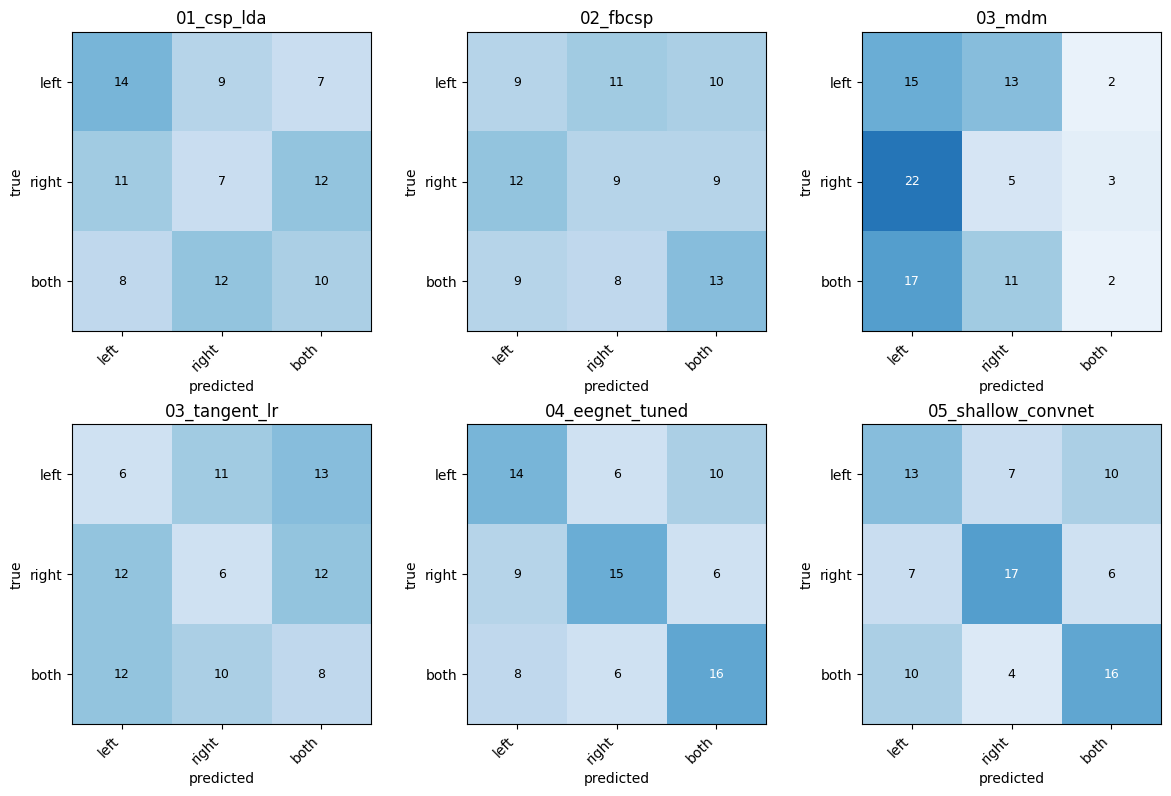

In [3]:
n = len(results)
cols = min(3, n)
rows_n = math.ceil(n / cols)
fig, axes = plt.subplots(rows_n, cols, figsize=(4 * cols, 4 * rows_n))
axes = np.atleast_1d(axes).flatten()
for ax, r in zip(axes, results):
    plot_confusion(np.array(r['result']['confusion']), r['classes'],
                   ax=ax, title=r['name'])
for ax in axes[len(results):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## Winner and deployment notes

In [4]:
winner_row = df.iloc[0]
winner_name = winner_row['model']
print('Winner:', winner_name)
print(winner_row.to_string())

DEPLOY_NOTES = {
    '01_csp_lda': (
        "Classical CSP+LDA — requires a new inference path in "
        "`eeg_online_classifier.py` that calls `pipeline.predict` on a "
        "(1, n_ch, n_samples) array instead of the Torch tensor path. "
        "Preprocessing is already identical."
    ),
    '02_fbcsp': (
        "FBCSP+LDA — same integration work as CSP. Note this pipeline "
        "was trained on a 1–45 Hz broad bandpass (not the 8–30 Hz "
        "default); the live preprocess() must widen the band to match."
    ),
    '03_mdm': (
        "Riemannian MDM — no learned weights, just class-mean covariance "
        "matrices. Live integration is a ~30-line pyriemann path."
    ),
    '03_tangent_lr': (
        "Riemannian TangentSpace+LR — same as MDM but with one LR on top."
    ),
    '04_eegnet_tuned': (
        "Drop-in replacement — the .pt checkpoint loads directly with "
        "`python eeg_online_classifier.py --model "
        "notebooks/results/04_eegnet_tuned.pt`, provided the tuned "
        "F1/D/kern_len/dropout match the values hardcoded in the "
        "EEGNet constructor there. If any differ, pass them through "
        "the saved `cfg` dict."
    ),
    '05_shallow_convnet': (
        "ShallowConvNet — requires pasting the architecture into "
        "`eeg_online_classifier.py` (or importing it) and extending "
        "`load_model` to branch on checkpoint['architecture']."
    ),
}
print('\nDeployment note:')
print(DEPLOY_NOTES.get(winner_name, 'No deployment note registered.'))

Winner: 04_eegnet_tuned
model              04_eegnet_tuned
accuracy             0.500 ± 0.061
precision_macro              0.535
recall_macro                   0.5
f1_macro             0.499 ± 0.063
f1_left                      0.458
f1_right                     0.524
f1_both                      0.515

Deployment note:
Drop-in replacement — the .pt checkpoint loads directly with `python eeg_online_classifier.py --model notebooks/results/04_eegnet_tuned.pt`, provided the tuned F1/D/kern_len/dropout match the values hardcoded in the EEGNet constructor there. If any differ, pass them through the saved `cfg` dict.


In [5]:
# Copy the winning checkpoint/pipeline to a canonical filename so it's
# trivial to point the online classifier at it.
import shutil
pt_path     = RESULTS_DIR / f'{winner_name}.pt'
joblib_path = RESULTS_DIR / f'{winner_name}.joblib'

if pt_path.exists():
    dst = RESULTS_DIR / 'best_model.pt'
    shutil.copy2(pt_path, dst)
    print('copied', pt_path.name, '→', dst.name)
    print('run: python eeg_online_classifier.py --model', dst)
elif joblib_path.exists():
    dst = RESULTS_DIR / 'best_model.joblib'
    shutil.copy2(joblib_path, dst)
    print('copied', joblib_path.name, '→', dst.name)
    print('classical pipeline — see deployment note above for integration steps.')
else:
    print('no artefact found for', winner_name)

copied 04_eegnet_tuned.pt → best_model.pt
run: python eeg_online_classifier.py --model /Users/macuser/Downloads/EEG Classifier/notebooks/results/best_model.pt
